# Import Libraries

In [71]:
import os
import numpy as np
import pylidc as pl
import matplotlib as plt
import matplotlib.pyplot as plt
import matplotlib.animation as manim
from PIL import Image
from pathlib import Path
from sqlalchemy import and_
from tabulate import tabulate
from pylidc.utils import consensus
from skimage.measure import find_contours

# Query The LIDC-IDRI Scans

In [72]:
scans = pl.query(pl.Scan).all()
print(f"Num of Patient: {len(scans)}")

Num of Patient: 1018


In [73]:
OUTPUT_PATH = "../datasets/images/lidc_idri_png"

Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.


KeyboardInterrupt: 

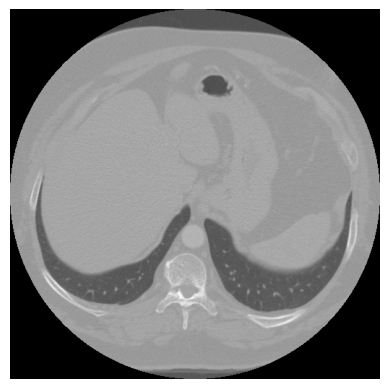

In [74]:

for scan in scans:
    output_path = os.path.join(OUTPUT_PATH, scan.patient_id)
    Path(output_path).mkdir(parents=True, exist_ok=True)
    vol = scan.to_volume()

    for slice_id in range(0, vol.shape[2]):
        array_slice = vol[:, :, slice_id]
        plt.imshow(array_slice, cmap='gray')
        plt.axis('off')
        plt.savefig(
            f"{output_path}/{slice_id}",
            bbox_inches='tight',
            pad_inches=0
        )
        plt.close()